# **ANEMIA CLASSIFICATION MODEL**

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("anemia.csv")

In [3]:
X = df.drop(columns=["Result"])
y = df["Result"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [5]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [8]:
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [9]:
best_model = grid_search.best_estimator_


In [10]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [12]:
print("Best Parameters:", grid_search.best_params_)
print("Model Accuracy:", accuracy)
print("ROC-AUC Score:", roc_auc)
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Model Accuracy: 1.0
ROC-AUC Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       161
           1       1.00      1.00      1.00       124

    accuracy                           1.00       285
   macro avg       1.00      1.00      1.00       285
weighted avg       1.00      1.00      1.00       285



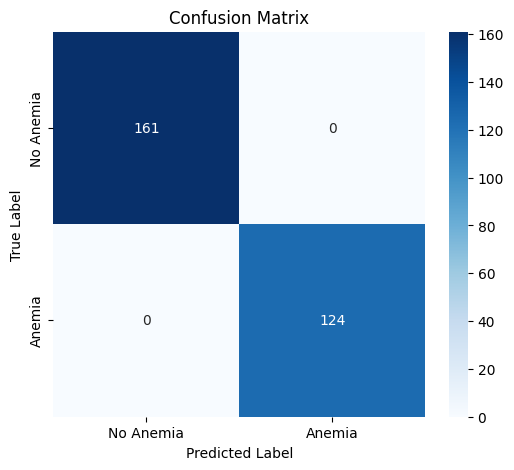

In [13]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Anemia', 'Anemia'], yticklabels=['No Anemia', 'Anemia'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [14]:
feature_importances = best_model.feature_importances_
feature_names = X.columns

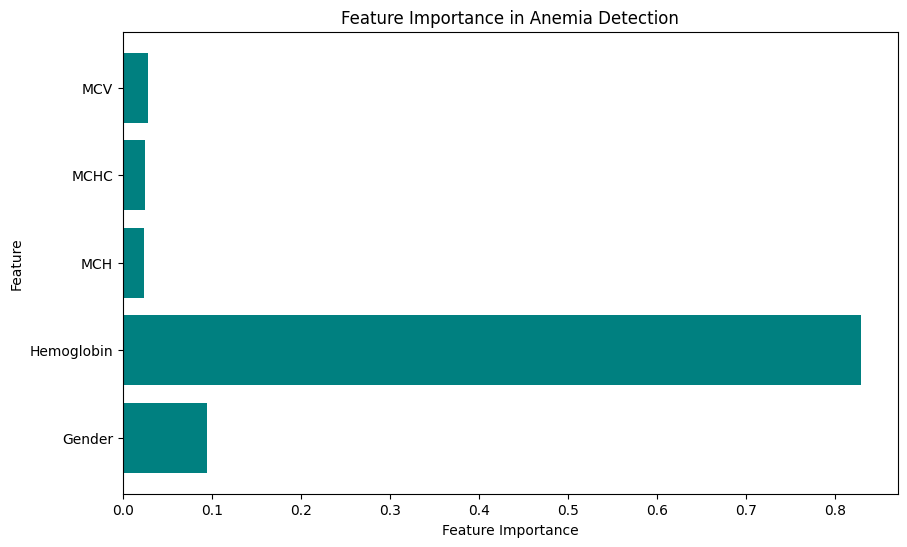

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances, color='teal')
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance in Anemia Detection")
plt.show()

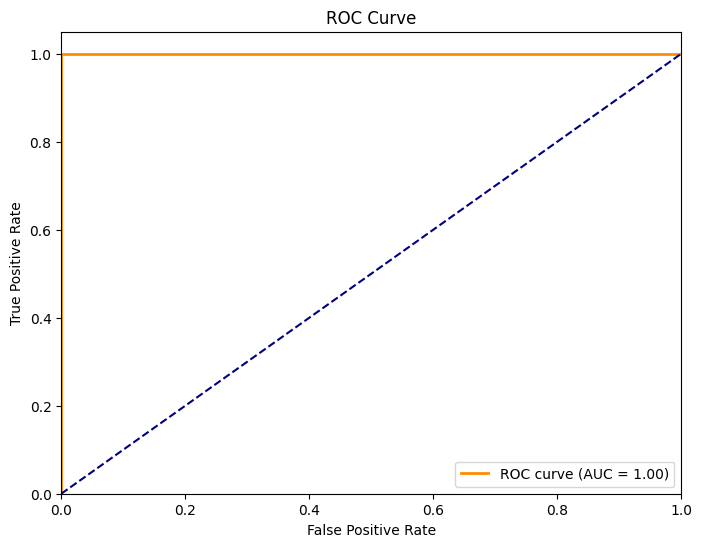

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [17]:
joblib.dump(best_model, "anemia_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [18]:
model = joblib.load("anemia_model.pkl")
scaler = joblib.load("scaler.pkl")

In [19]:
new_test_data = np.array([
    [0, 7.5, 18.0, 2.8, 8.0],
    [1, 16.0, 40.0, 5.0, 15.5],
    [0, 12.0, 32.0, 4.2, 12.8]
])

In [20]:
new_data_scaled = scaler.transform(new_test_data)


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
predictions = model.predict(new_data_scaled)


In [22]:
for i, pred in enumerate(predictions):
    if pred == 1:
        print(f"\033[91mCase {i+1}: Detected Anemia\033[0m")
    else:
        print(f"\033[92mCase {i+1}: Not Detected Anemia\033[0m")

Case 1: Detected Anemia
Case 2: Not Detected Anemia
Case 3: Detected Anemia
